# Social Network Analysis - BT Asia Pacific Topology

This case study applies **Social Network Analysis (SNA)** to a real-world telecommunications network (BT Asia Pacific), treating routers/PoPs as nodes and fibre links as edges.

In [93]:
!pip install networkx matplotlib requests numpy --quiet

In [94]:
Bgraph      = "#0f1117"
EDgraphE_C  = "#3a4a6b"
NODE_C  = "#4fc3f7"
LABEL_C = "#e0e0e0"

## Downloading the datasets
The dataset that I will be using is the Topology Data for Bt Asia Pacific from Topology Zoo. Topology Zoo is a website that tracks the topology of networks of companies.

In [95]:
import requests, hashlib, os

url       = "https://topology-zoo.org/files/BtAsiaPac.graphml"
file_name = "BtAsiaPac.graphml"
file_hash = "5e97686968b16a76477298974e6e0928bac2f467fc43adda4782454bda7700cb"

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

if os.path.exists(file_name) and sha256_file(file_name) == file_hash:
    print("File already verified.")
else:
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(file_name, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    assert sha256_file(file_name) == file_hash, "Hash mismatch!"
    print("Downloaded and verified.")

File already verified.


## 1. Load the graphraph

In [96]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from collections import Counter

graph = nx.read_graphml(file_name)

print(f"Nodes : {graph.number_of_nodes()}")
print(f"Edges : {graph.number_of_edges()}")

print("\nNode attributes:")
for i, (num, data) in enumerate(graph.nodes(data=True)):
    print(f"  {num}: {data}")
    if i >= 3: break

Nodes : 20
Edges : 31

Node attributes:
  0: {'Internal': 1, 'Latitude': -6.21462, 'Country': 'Indonesia', 'id': 0, 'Longitude': 106.84513, 'label': 'Jakarta'}
  1: {'Internal': 1, 'Latitude': -31.93333, 'Country': 'Australia', 'id': 1, 'Longitude': 115.83333, 'label': 'Perth'}
  2: {'Internal': 1, 'Latitude': 1.28967, 'Country': 'Singapore', 'id': 2, 'Longitude': 103.85007, 'label': 'Singapore'}
  3: {'Internal': 1, 'Latitude': 3.1412, 'Country': 'Malaysia', 'id': 3, 'Longitude': 101.68653, 'label': 'Kuala Lumpur'}


## 2. Network Overview Visualisation

Node size scales with **degree** (number of connections). Labels show city names where available.

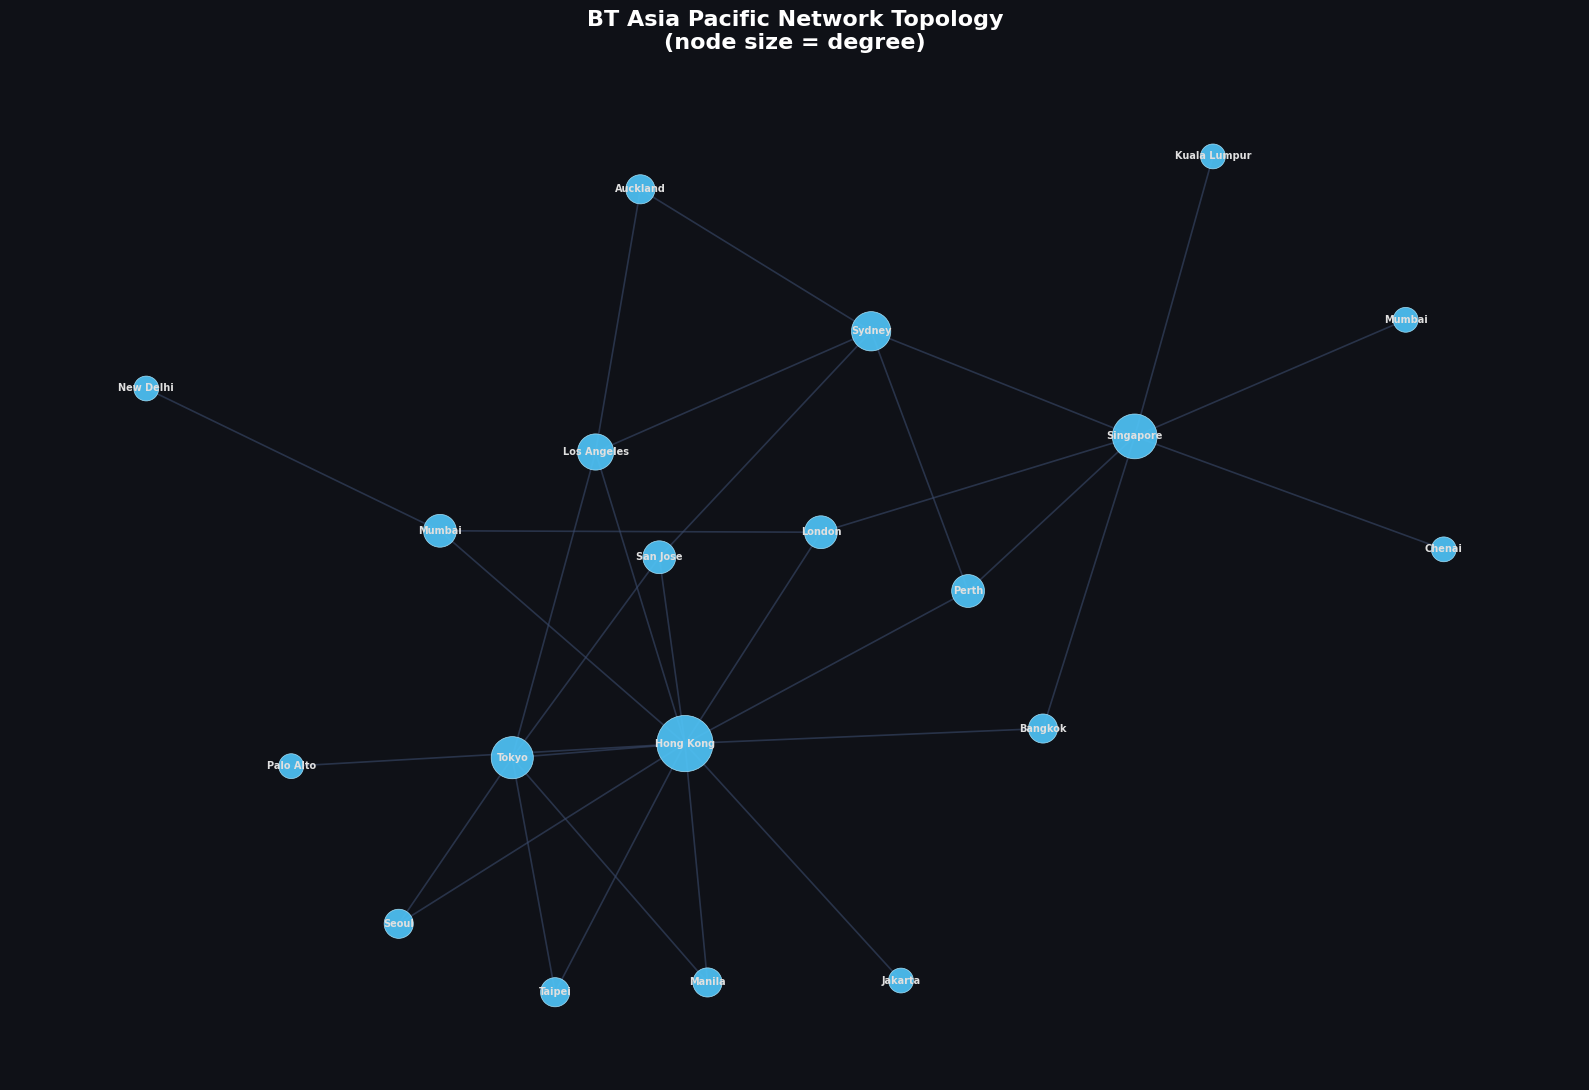

In [ ]:
pos = nx.kamada_kawai_layout(graph)
degrees    = dict(graph.degree())
node_sizes = [200 + degrees[n] * 120 for n in graph.nodes()]
labels = {n: graph.nodes[n].get('label', n) for n in graph.nodes()}

fig, ax = plt.subplots(figsize=(16, 11), facecolor=Bgraph)
ax.set_facecolor(Bgraph)

nx.draw_networkx_edges(graph, pos, ax=ax, edge_color=EDgraphE_C, width=1.2, alpha=0.6)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=node_sizes,node_color=NODE_C, alpha=0.92, linewidths=0.5, edgecolors="#aee8ff")
nx.draw_networkx_labels(graph, pos, labels, ax=ax, font_size=7, font_color=LABEL_C, font_weight="bold")

ax.set_title("BT Asia Pacific Network Topology\n(node size = degree)", color="white", fontsize=16, fontweight="bold", pad=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Centrality Analysis

| Metric | What it measures | Node role |
|--------|-----------------|----------|
| **Degree centrality** | direct connections | Hub |
| **Betweenness centrality** | how often on shortest paths | Broker / bridge |
| **Closeness centrality** | average distance to all others | Reachable node |
| **Eigenvector centrality** | quality of neighbours | Influencer |

In [98]:
deg_cent = nx.degree_centrality(graph)
bet_cent = nx.betweenness_centrality(graph, normalized=True)
clo_cent = nx.closeness_centrality(graph)
eig_cent = nx.eigenvector_centrality(graph, max_iter=1000)

for node in graph.nodes():
    graph.nodes[node]['degree_c']      = deg_cent[node]
    graph.nodes[node]['betweenness_c'] = bet_cent[node]
    graph.nodes[node]['closeness_c']   = clo_cent[node]
    graph.nodes[node]['eigenvector_c'] = eig_cent[node]

def top_k(metric, k=5):
    return sorted(metric.items(), key=lambda x: x[1], reverse=True)[:k]

def display_top(title, metric, k=5):
    print(f"\n{'─'*50}")
    print(f"  {title}")
    print(f"{'─'*50}")
    for node, val in top_k(metric, k):
        name = graph.nodes[node].get('label', node)
        print(f"  {name:<22} {val:.4f}")

display_top("Top Eigenvector (Influencers)", eig_cent)
display_top("Top Betweenness  (Brokers)",   bet_cent)
display_top("Top Degree       (Hubs)",       deg_cent)
display_top("Top Closeness",                 clo_cent)


──────────────────────────────────────────────────
  Top Eigenvector (Influencers)
──────────────────────────────────────────────────
  Hong Kong              0.5503
  Tokyo                  0.3695
  Los Angeles            0.2778
  San Jose               0.2531
  Sydney                 0.2352

──────────────────────────────────────────────────
  Top Betweenness  (Brokers)
──────────────────────────────────────────────────
  Hong Kong              0.5645
  Singapore              0.3275
  Mumbai                 0.1053
  Sydney                 0.1049
  London                 0.1012

──────────────────────────────────────────────────
  Top Degree       (Hubs)
──────────────────────────────────────────────────
  Hong Kong              0.6316
  Singapore              0.3684
  Tokyo                  0.3158
  Sydney                 0.2632
  Los Angeles            0.2105

──────────────────────────────────────────────────
  Top Closeness
──────────────────────────────────────────────────
  Hon

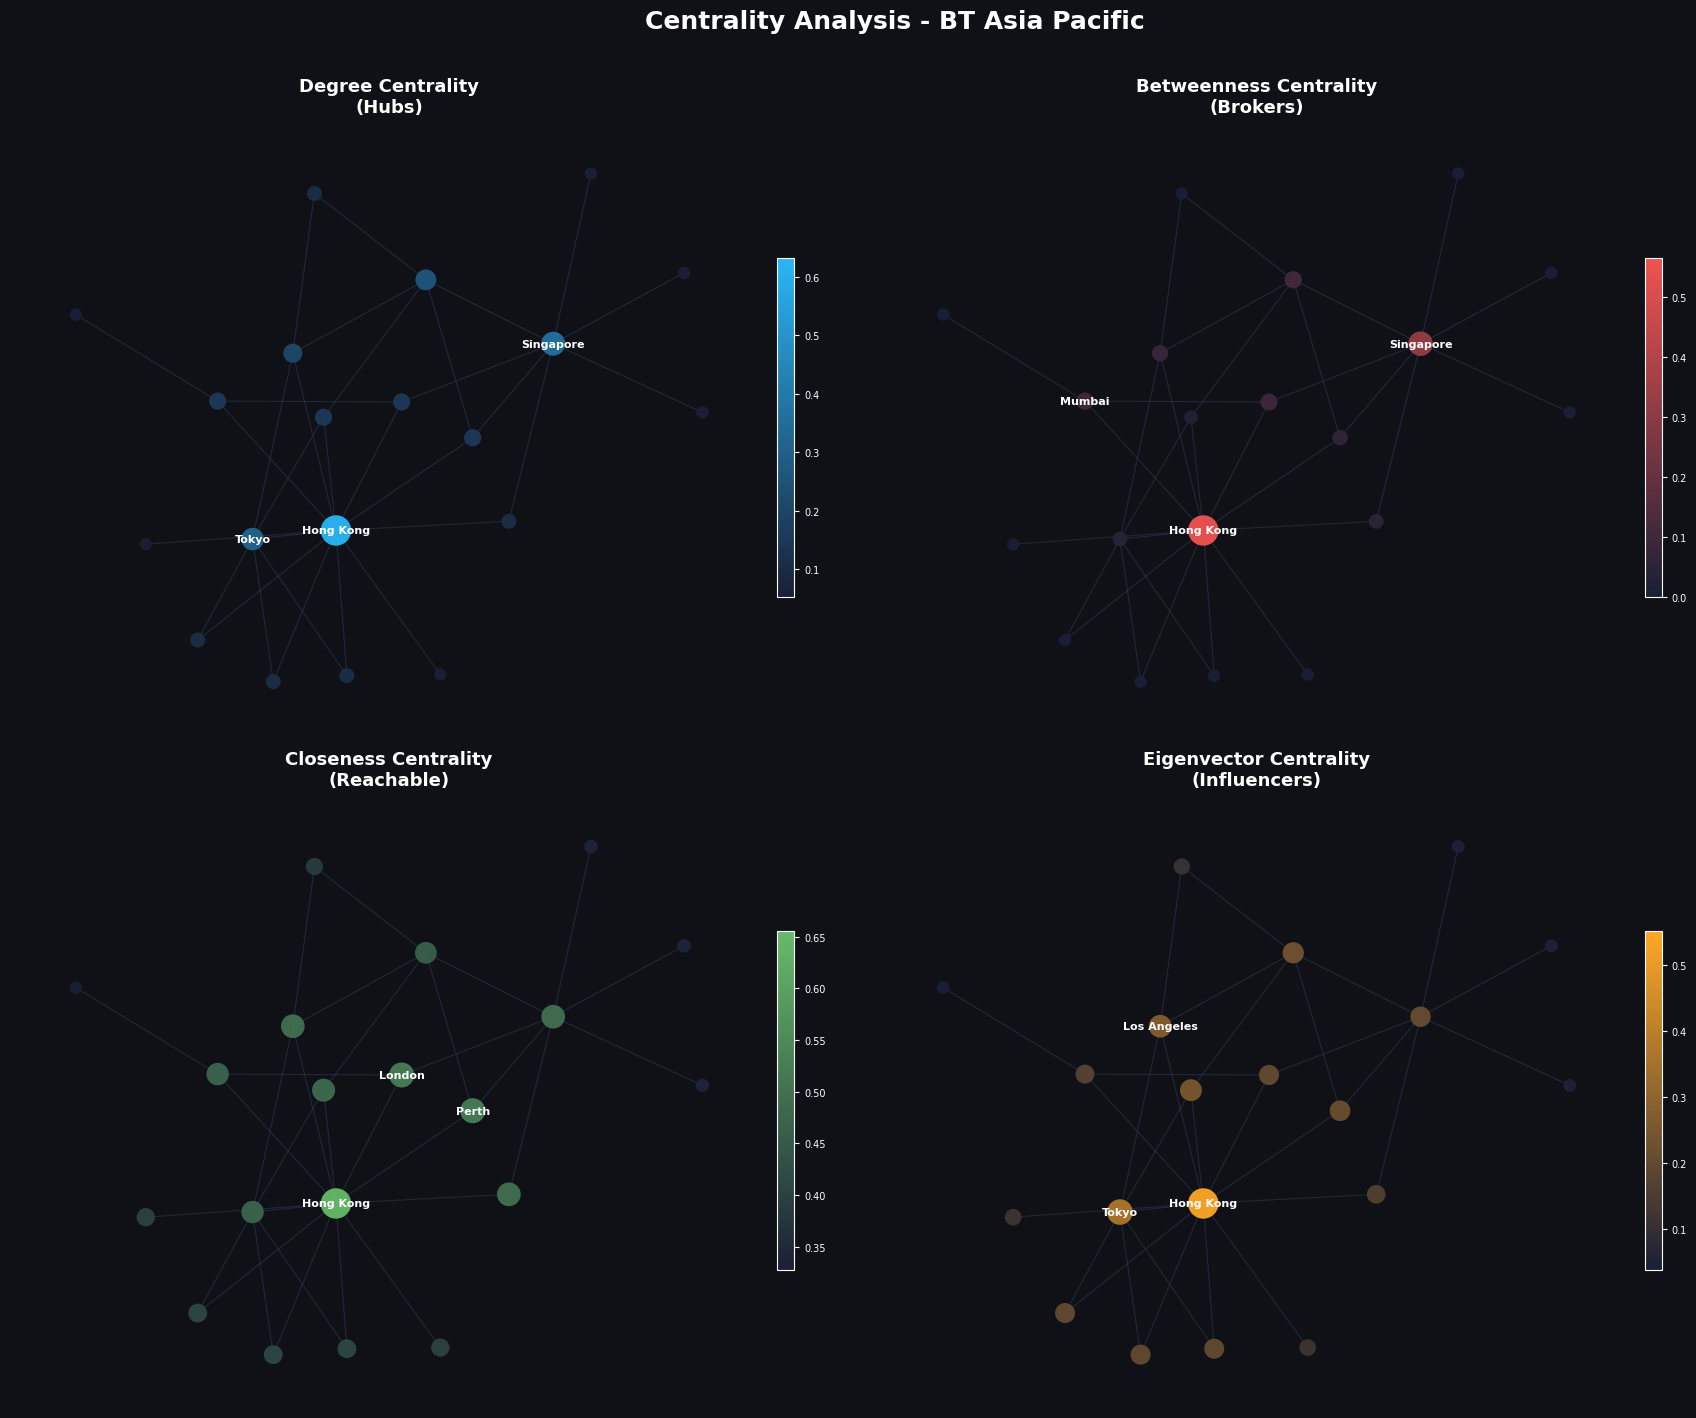

In [ ]:
# ── 4-panel centrality heatmap ───────────────────────────────────────────────
metrics = [
    (deg_cent, "Degree Centrality",      "Hubs",        "#29b6f6"),
    (bet_cent, "Betweenness Centrality", "Brokers",     "#ef5350"),
    (clo_cent, "Closeness Centrality",   "Reachable",   "#66bb6a"),
    (eig_cent, "Eigenvector Centrality", "Influencers", "#ffa726"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor=Bgraph)
axes = axes.flatten()

for ax, (metric, title, role, accent) in zip(axes, metrics):
    ax.set_facecolor(Bgraph)
    vals  = np.array([metric[n] for n in graph.nodes()])
    normed = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    cmap  = mcolors.LinearSegmentedColormap.from_list("c", ["#1a1f36", accent])
    ncolors = [cmap(v) for v in normed]
    nsizes  = [80 + v * 400 for v in normed]

    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color=EDgraphE_C, width=0.8, alpha=0.4)
    nc = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=nsizes, node_color=ncolors, linewidths=0, alpha=0.95)

    top3 = dict(top_k(metric, 3))
    top3_labels = {n: graph.nodes[n].get('label', n) for n in top3}
    nx.draw_networkx_labels(graph, pos, top3_labels, ax=ax, font_size=8, font_color="white", font_weight="bold")

    ax.set_title(f"{title}\n({role})", color="white", fontsize=13, fontweight="bold")
    ax.axis("off")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vals.min(), vals.max()))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.01)
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=7)
    cb.outline.set_edgecolor("white")

fig.suptitle("Centrality Analysis - BT Asia Pacific", color="white", fontsize=18, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. graphlobal Network Metrics

graphlobal metrics describe the **overall structure and efficiency** of the network.

In [ ]:
graphu = graph.to_undirected() if graph.is_directed() else graph

lcc = graphu.subgraph(max(nx.connected_components(graphu), key=len)).copy()

density = nx.density(graphu)
n_nodes = graphu.number_of_nodes()
n_edges = graphu.number_of_edges()
avg_degree = sum(d for _, d in graphu.degree()) / n_nodes
clustering_global = nx.average_clustering(graphu)
transitivity = nx.transitivity(graphu)
diameter = nx.diameter(lcc)
avg_path_len = nx.average_shortest_path_length(lcc)
assortativity = nx.degree_assortativity_coefficient(graphu)

metrics_table = [
    ("Nodes", n_nodes, ""),
    ("Edges", n_edges, ""),
    ("Density", density, "sparse < 0.1, dense > 0.5"),
    ("Average Degree", avg_degree, "connections per node"),
    ("Average Clustering Coeff.", clustering_global, "local cliquishness (0-1)"),
    ("Transitivity", transitivity, "global clustering coeff."),
    ("Diameter (LCC)", diameter, "longest shortest path"),
    ("Avg. Shortest Path (LCC)", avg_path_len, "small-world if low"),
    ("Degree Assortativity", assortativity, "+ hubs link to hubs"),
]

print(f"{'Metric':<30} {'Value':>10}   Notes")
print("─" * 70)
for name, val, note in metrics_table:
    if isinstance(val, float):
        print(f"  {name:<28} {val:>10.4f}   {note}")
    else:
        print(f"  {name:<28} {val:>10}   {note}")

Metric                              Value   Notes
──────────────────────────────────────────────────────────────────────
  Nodes                                20   
  Edges                                31   
  Density                          0.1632   sparse < 0.1, dense > 0.5
  Average Degree                   3.1000   connections per node
  Average Clustering Coeff.        0.3169   local cliquishness (0-1)
  Transitivity                     0.1778   global clustering coeff.
  Diameter (LCC)                        4   longest shortest path
  Avg. Shortest Path (LCC)         2.3211   small-world if low
  Degree Assortativity            -0.5513   + hubs link to hubs


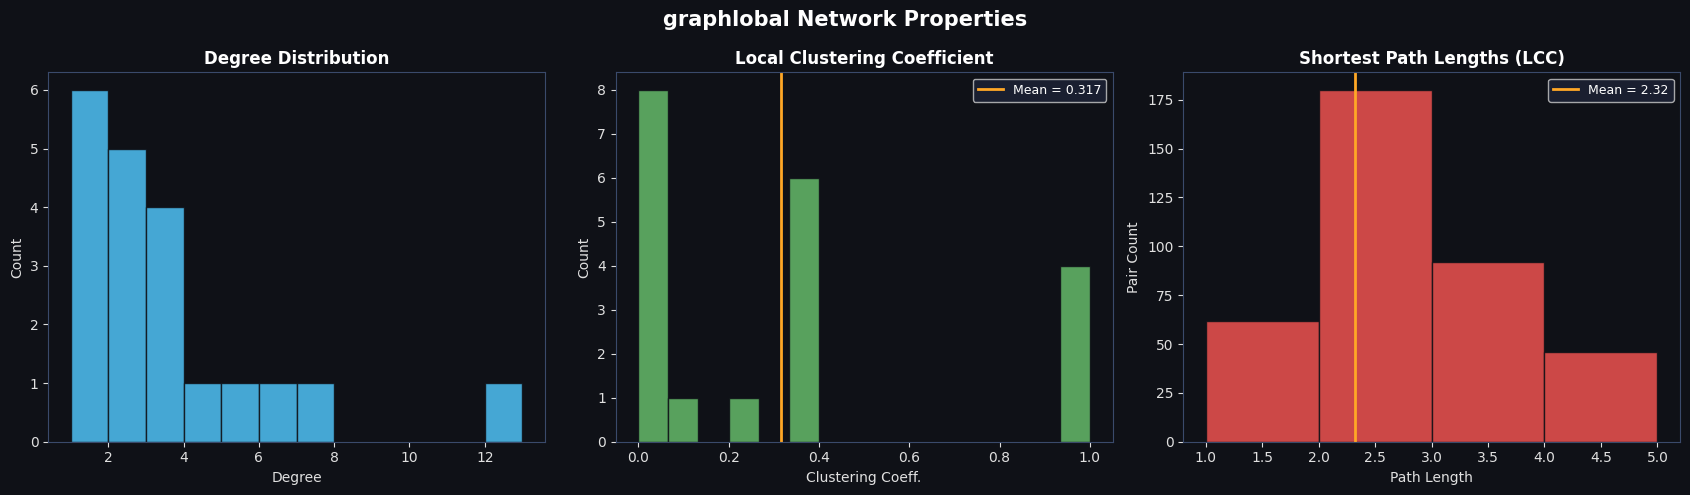

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=Bgraph)

ax = axes[0]
ax.set_facecolor(Bgraph)

deg_vals = [d for _, d in graphu.degree()]

ax.hist(deg_vals, bins=range(1, max(deg_vals)+2), color="#4fc3f7", edgecolor="#0f1117", alpha=0.85)
ax.set_title("Degree Distribution", color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("Degree", color=LABEL_C)
ax.set_ylabel("Count",  color=LABEL_C)
ax.tick_params(colors=LABEL_C)

for spine in ax.spines.values(): spine.set_edgecolor(EDgraphE_C)

ax = axes[1]
ax.set_facecolor(Bgraph)

cc_vals = list(nx.clustering(graphu).values())

ax.hist(cc_vals, bins=15, color="#66bb6a", edgecolor="#0f1117", alpha=0.85)
ax.axvline(clustering_global, color="#ffa726", lw=2, label=f"Mean = {clustering_global:.3f}")
ax.set_title("Local Clustering Coefficient", color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("Clustering Coeff.", color=LABEL_C)
ax.set_ylabel("Count",             color=LABEL_C)
ax.tick_params(colors=LABEL_C)
ax.legend(facecolor="#1e2337", labelcolor="white", fontsize=9)

for spine in ax.spines.values(): spine.set_edgecolor(EDgraphE_C)

ax = axes[2]
ax.set_facecolor(Bgraph)

path_lens = [l for _, lengths in nx.all_pairs_shortest_path_length(lcc) for l in lengths.values() if l > 0]

ax.hist(path_lens, bins=range(1, diameter+2), color="#ef5350", edgecolor="#0f1117", alpha=0.85)
ax.axvline(avg_path_len, color="#ffa726", lw=2, label=f"Mean = {avg_path_len:.2f}")
ax.set_title("Shortest Path Lengths (LCC)", color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("Path Length", color=LABEL_C)
ax.set_ylabel("Pair Count",  color=LABEL_C)
ax.tick_params(colors=LABEL_C)
ax.legend(facecolor="#1e2337", labelcolor="white", fontsize=9)

for spine in ax.spines.values(): spine.set_edgecolor(EDgraphE_C)

fig.suptitle("graphlobal Network Properties", color="white", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Community / Cluster Detection

We use the **graphreedy Modularity** algorithm (Clauset-Newman-Moore), which maximises the **modularity score Q** - a measure of how well-separated communities are (Q → 1 means perfect separation, Q → 0 means random).

In [102]:
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

communities = list(greedy_modularity_communities(graphu))
Q = modularity(graphu, communities)

print(f"Communities detected : {len(communities)}")
print(f"Modularity (Q)       : {Q:.4f}  (> 0.3 = meaningful structure)")
print()
for i, comm in enumerate(communities):
    names = [graph.nodes[n].get('label', n) for n in comm]
    print(f"  Cluster {i+1} ({len(comm)} nodes): {', '.join(sorted(names))}")

for i, comm in enumerate(communities):
    for node in comm:
        graph.nodes[node]['cluster'] = i

Communities detected : 4
Modularity (Q)       : 0.3574  (> 0.3 = meaningful structure)

  Cluster 1 (8 nodes): Hong Kong, Jakarta, Manila, Palo Alto, San Jose, Seoul, Taipei, Tokyo
  Cluster 2 (5 nodes): Bangkok, Chenai, Kuala Lumpur, Mumbai, Singapore
  Cluster 3 (4 nodes): Auckland, Los Angeles, Perth, Sydney
  Cluster 4 (3 nodes): London, Mumbai, New Delhi


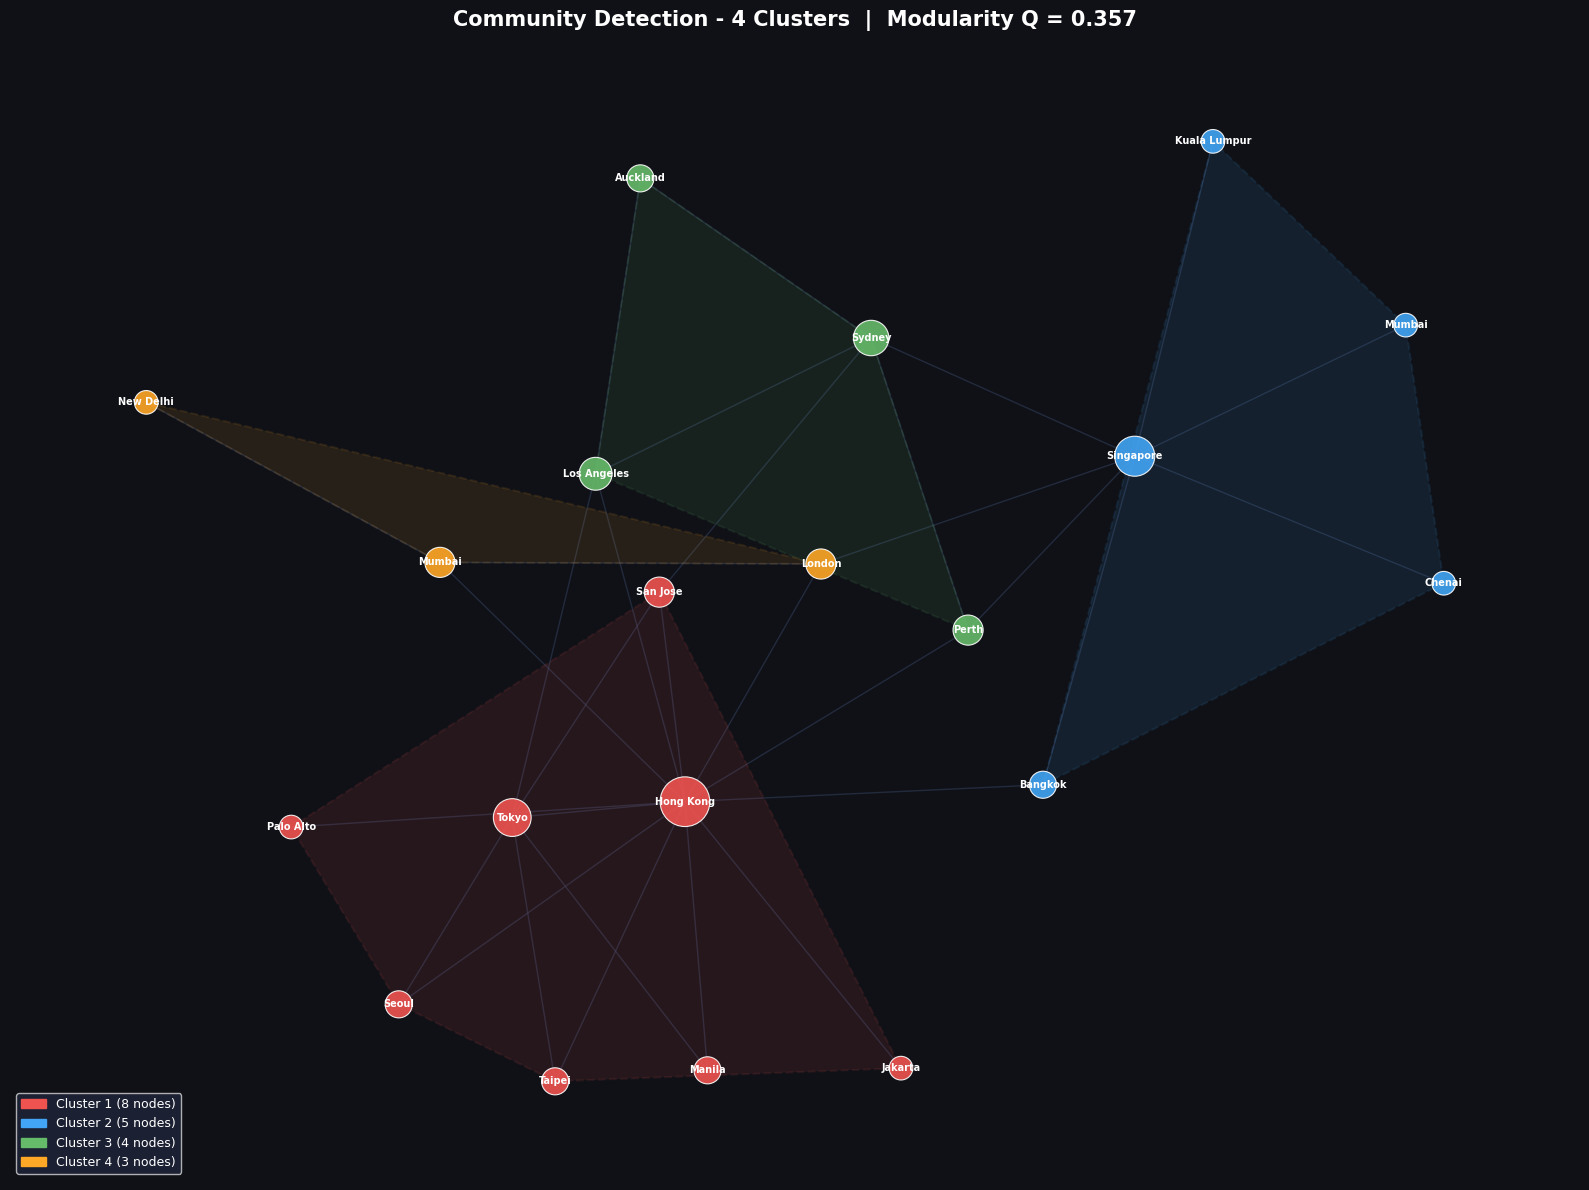

In [ ]:
# ── Cluster visualisation with convex hulls ──────────────────────────────────
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import ConvexHull
import itertools

random_colors = [ "#ef5350", "#42a5f5", "#66bb6a", "#ffa726", "#ab47bc", "#26c6da", "#d4e157", "#ff7043", "#8d6e63", "#78909c" ]

fig, ax = plt.subplots(figsize=(16, 12), facecolor=Bgraph)
ax.set_facecolor(Bgraph)

nx.draw_networkx_edges(graph, pos, ax=ax, edge_color=EDgraphE_C, width=1.0, alpha=0.45)

cluster_attr = nx.get_node_attributes(graph, 'cluster')
ncolors = [random_colors[cluster_attr[n] % len(random_colors)] for n in graph.nodes()]
node_sizes_cl = [200 + degrees[n] * 90 for n in graph.nodes()]

nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=node_sizes_cl, node_color=ncolors, linewidths=0.8, edgecolors="white", alpha=0.9)
nx.draw_networkx_labels(graph, pos, labels, ax=ax, font_size=7, font_color="white", font_weight="bold")

for i, comm in enumerate(communities):
    pts = np.array([pos[n] for n in comm])
    if len(pts) < 3:
        continue
    try:
        hull  = ConvexHull(pts)
        color = random_colors[i % len(random_colors)]
        poly  = MplPolygon(pts[hull.vertices], closed=True, alpha=0.10, facecolor=color, edgecolor=color, linewidth=1.5, linestyle="--")
        ax.add_patch(poly)
    except Exception:
        pass

patches = [
    mpatches.Patch(color=random_colors[i % len(random_colors)], label=f"Cluster {i+1} ({len(c)} nodes)")
    for i, c in enumerate(communities)
]
ax.legend(handles=patches, loc="lower left", facecolor="#1e2337", labelcolor="white", fontsize=9, framealpha=0.85)
ax.set_title(f"Community Detection - {len(communities)} Clusters  |  Modularity Q = {Q:.3f}", color="white", fontsize=15, fontweight="bold", pad=12)
ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Node Role Classification

We classify each node by combining centrality scores:

| Role | Criterion |
|-|-|
|**Influencer** | Top 10% eigenvector |
|**Broker** | Top 10% betweenness |
|**Hub** | Top 10% degree |
|**Peripheral** | others |

In [104]:
eig_thr = np.percentile(list(eig_cent.values()), 90)
bet_thr = np.percentile(list(bet_cent.values()), 90)
deg_thr = np.percentile(list(deg_cent.values()), 90)

roles = {}
for n in graph.nodes():
    if eig_cent[n] >= eig_thr:
        roles[n] = "influencer"
    elif bet_cent[n] >= bet_thr:
        roles[n] = "broker"
    elif deg_cent[n] >= deg_thr:
        roles[n] = "hub"
    else:
        roles[n] = "peripheral"
    graph.nodes[n]['role'] = roles[n]

role_counts = Counter(roles.values())
print("Role distribution:")
for role, count in role_counts.most_common():
    print(f"  {role:<12}: {count}")

print("\nIdentified nodes:")
for role in ["influencer", "broker", "hub"]:
    ns = [n for n, r in roles.items() if r == role]
    names = [graph.nodes[n].get('label', n) for n in ns]
    print(f"  {role.capitalize():<12}: {', '.join(sorted(names))}")

Role distribution:
  peripheral  : 17
  influencer  : 2
  broker      : 1

Identified nodes:
  Influencer  : Hong Kong, Tokyo
  Broker      : Singapore
  Hub         : 


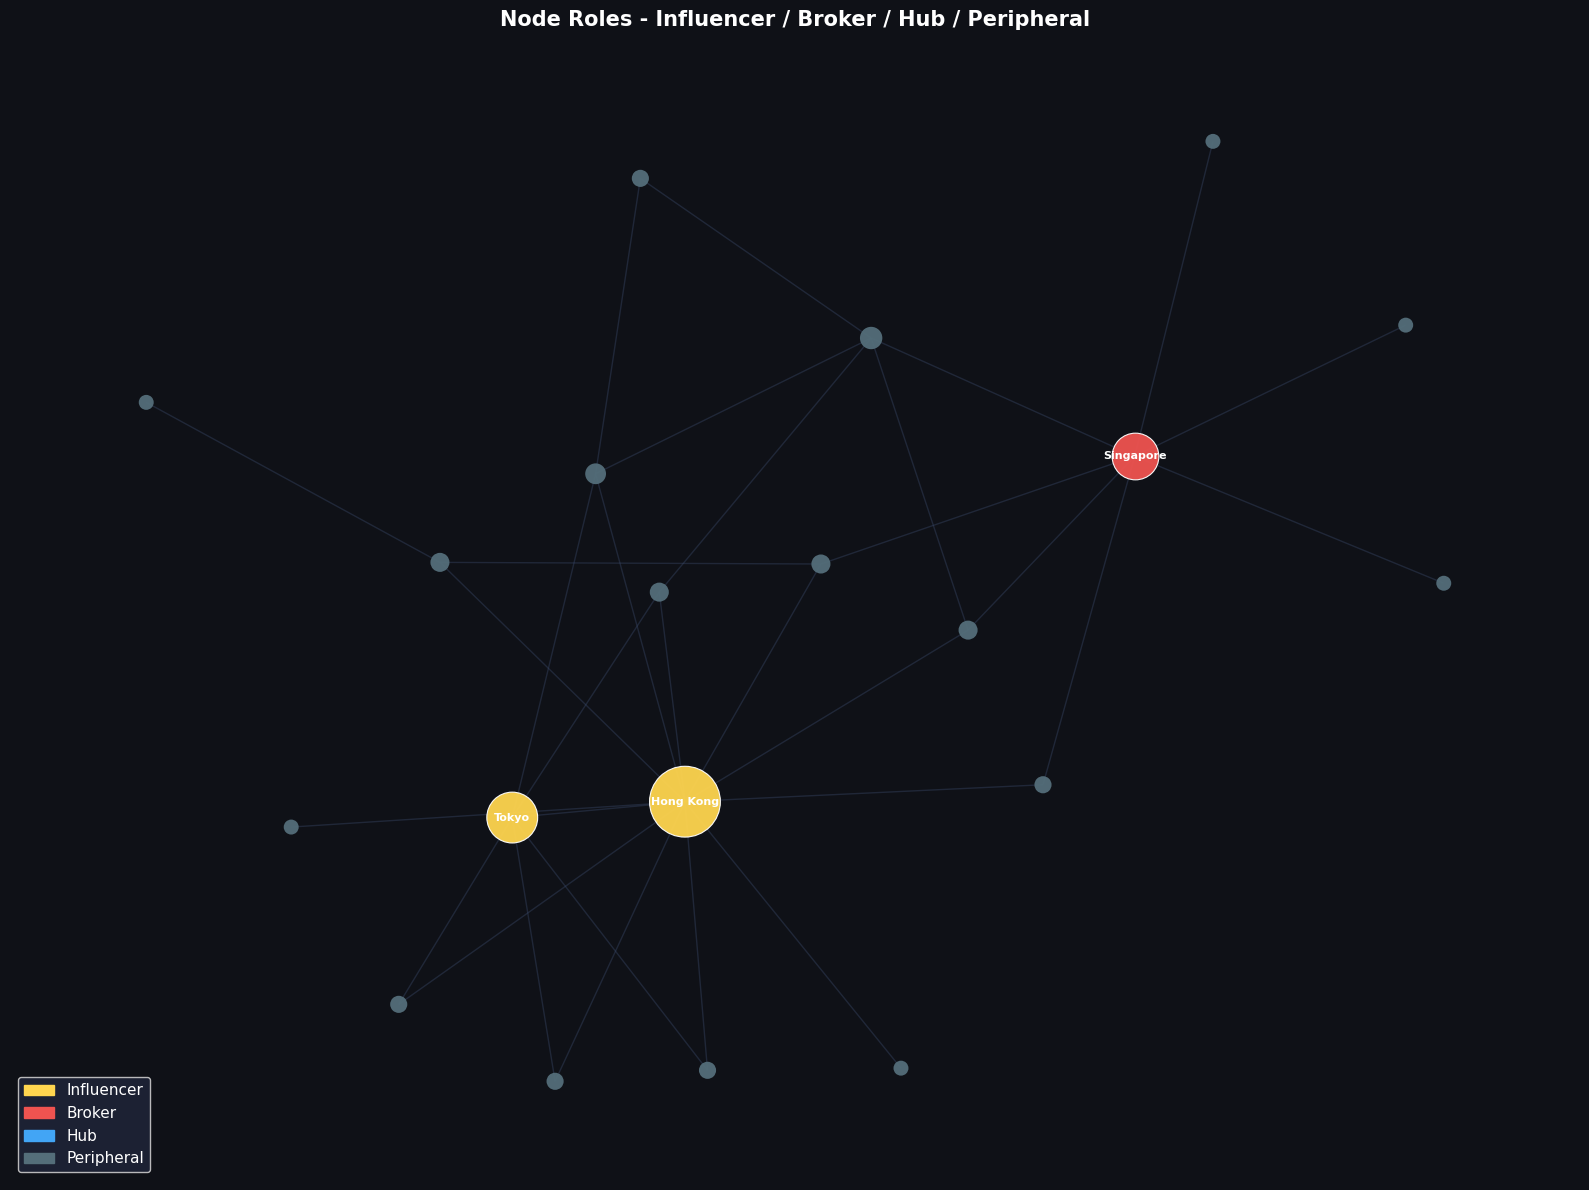

In [ ]:
role_style = {
    "influencer":{"color": "#ffd54f", "marker": "I", "size_mult": 3.5, "label": "Influencer"},
    "broker": {"color": "#ef5350", "marker": "D", "size_mult": 2.5, "label": "Broker"},
    "hub": {"color": "#42a5f5", "marker": "H", "size_mult": 1.8, "label": "Hub"},
    "peripheral":{"color": "#546e7a", "marker": "P", "size_mult": 0.6, "label": "Peripheral"},
}

fig, ax = plt.subplots(figsize=(16, 12), facecolor=Bgraph)
ax.set_facecolor(Bgraph)

nx.draw_networkx_edges(graph, pos, ax=ax, edge_color=EDgraphE_C, width=1.0, alpha=0.4)

for role, style in role_style.items():
    nodes_r  = [n for n in graph.nodes() if roles[n] == role]
    sizes_r  = [80 + degrees[n] * style["size_mult"] * 60 for n in nodes_r]
    nx.draw_networkx_nodes(graph, pos, nodelist=nodes_r, ax=ax, node_size=sizes_r, node_color=style["color"], linewidths=0.8 if role != "peripheral" else 0, edgecolors="white", alpha=0.95)

# Labels only for non-peripheral
highlight_nodes = {n: graph.nodes[n].get('label', n) for n in graph.nodes() if roles[n] != "peripheral"}
nx.draw_networkx_labels(
    graph, pos, highlight_nodes, ax=ax,
    font_size=8, font_color="white", font_weight="bold"
)

patches = [mpatches.Patch(color=s["color"], label=s["label"]) for s in role_style.values()]

ax.legend(handles=patches, loc="lower left", facecolor="#1e2337", labelcolor="white", fontsize=11, framealpha=0.9)
ax.set_title("Node Roles - Influencer / Broker / Hub / Peripheral", color="white", fontsize=15, fontweight="bold", pad=12)
ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Summary Dashboard

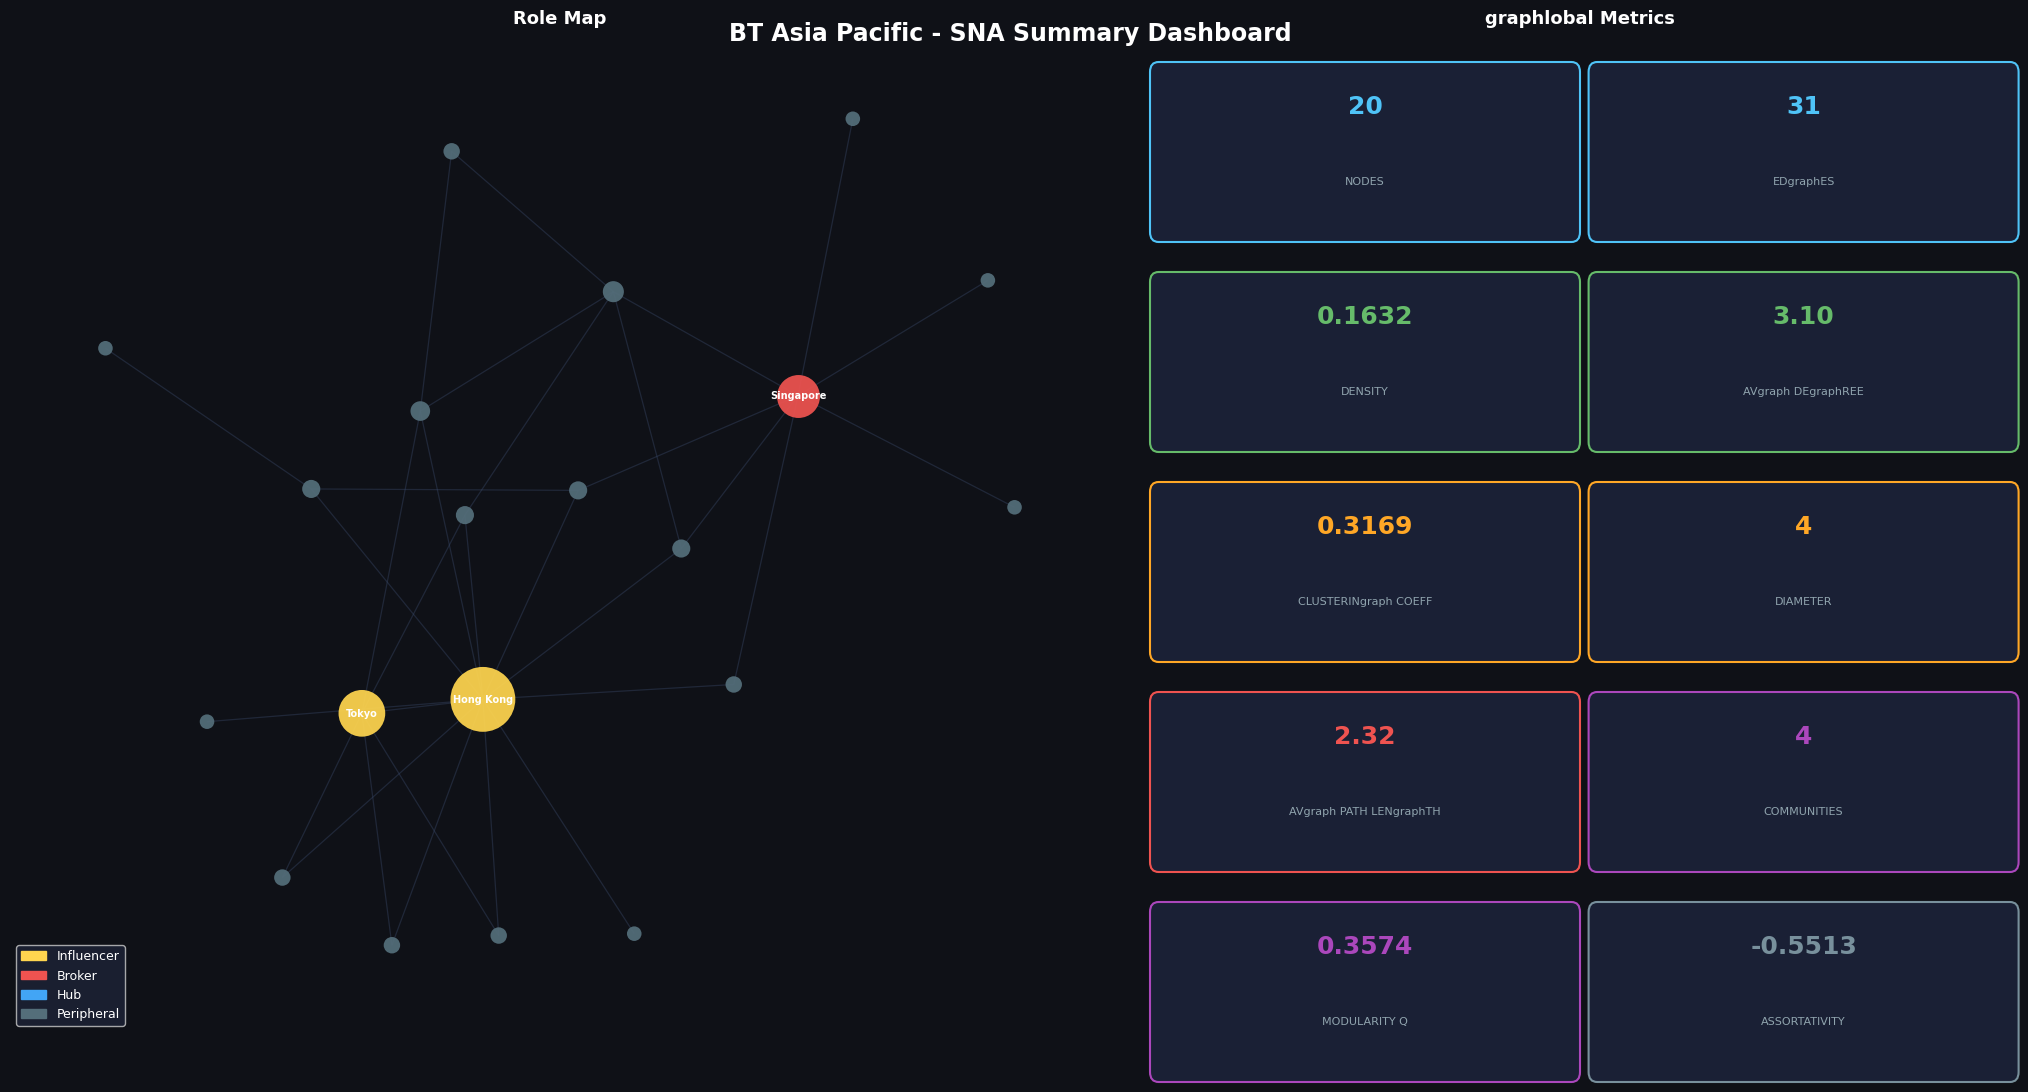

All figures saved.


In [ ]:
fig = plt.figure(figsize=(20, 10), facecolor=Bgraph)

ax_map = fig.add_axes([0.0, 0.0, 0.55, 1.0])
ax_map.set_facecolor(Bgraph)

nx.draw_networkx_edges(graph, pos, ax=ax_map, edge_color=EDgraphE_C, width=0.9, alpha=0.4)
for role, style in role_style.items():
    nodes_r = [n for n in graph.nodes() if roles[n] == role]
    sizes_r = [80 + degrees[n] * style["size_mult"] * 50 for n in nodes_r]
    nx.draw_networkx_nodes(graph, pos, nodelist=nodes_r, ax=ax_map, node_size=sizes_r, node_color=style["color"], linewidths=0, alpha=0.93)

nx.draw_networkx_labels(graph, pos, highlight_nodes, ax=ax_map, font_size=7, font_color="white", font_weight="bold")
patches = [mpatches.Patch(color=s["color"], label=s["label"]) for s in role_style.values()]

ax_map.legend(handles=patches, loc="lower left", facecolor="#1e2337", labelcolor="white", fontsize=9)
ax_map.set_title("Role Map", color="white", fontsize=13, fontweight="bold")
ax_map.axis("off")

ax_stats = fig.add_axes([0.57, 0.0, 0.43, 1.0])
ax_stats.set_facecolor(Bgraph)
ax_stats.axis("off")

cards = [
    ("NODES", str(n_nodes), "#4fc3f7"),
    ("EDgraphES", str(n_edges), "#4fc3f7"),
    ("DENSITY", f"{density:.4f}", "#66bb6a"),
    ("AVgraph DEgraphREE", f"{avg_degree:.2f}", "#66bb6a"),
    ("CLUSTERINgraph COEFF", f"{clustering_global:.4f}", "#ffa726"),
    ("DIAMETER", str(diameter), "#ffa726"),
    ("AVgraph PATH LENgraphTH", f"{avg_path_len:.2f}", "#ef5350"),
    ("COMMUNITIES", str(len(communities)), "#ab47bc"),
    ("MODULARITY Q", f"{Q:.4f}", "#ab47bc"),
    ("ASSORTATIVITY", f"{assortativity:.4f}","#78909c"),
]

cols, rows = 2, 5
cw, rh = 0.48, 0.18
for idx, (label, val, color) in enumerate(cards):
    c, r = idx % cols, idx // cols
    x = 0.01 + c * (cw + 0.03)
    y = 0.97 - r * (rh + 0.03)
    rect = mpatches.FancyBboxPatch((x, y - rh + 0.01), cw, rh - 0.02, boxstyle="round,pad=0.01", facecolor="#1a2035", edgecolor=color, linewidth=1.5, transform=ax_stats.transAxes, clip_on=False )
    ax_stats.add_patch(rect)
    ax_stats.text(x + cw/2, y - rh/2 + 0.045, val, color=color, fontsize=18, fontweight="bold", ha="center", va="center", transform=ax_stats.transAxes)
    ax_stats.text(x + cw/2, y - rh/2 - 0.030, label, color="#90a4ae", fontsize=8, ha="center", va="center", transform=ax_stats.transAxes)

ax_stats.set_title("graphlobal Metrics", color="white", fontsize=13, fontweight="bold")

fig.suptitle("BT Asia Pacific - SNA Summary Dashboard", color="white", fontsize=17, fontweight="bold", y=1.01)

plt.show()